In [ ]:
similaritatea cosinus/ cu TF-IDF

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Lista de documente (de exemplu, fiecare cuvânt ca un document)
documents = ["PREZENTA CURS SI SEMINAR", "seminar"]

# Crearea vectorizatorului TF-IDF
vectorizer = TfidfVectorizer()

# Transformarea documentelor în matrice TF-IDF
tfidf_matrix = vectorizer.fit_transform(documents)

# Calcularea similarității cosinus
similarity_matrix = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])

print(f"Similaritatea cosinus cu TF-IDF între 'curs' și 'seminar' este: {similarity_matrix[0][0]}")


Similaritatea cosinus cu TF-IDF între 'curs' și 'seminar' este: 0.37997836159100784


# similaritatea cosinus/ cu TF-IDF

In [7]:
pip install gensim

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
#https://fasttext.cc/docs/en/crawl-vectors.html

from gensim.models import KeyedVectors
import os

#  Specifica calea catre modelul FastText pentru romana 
model_path = r"C:\Users\Mironela Pirnau\Downloads\cc.ro.300.bin"

#  Verificam daca fisierul exista 
if not os.path.exists(model_path):
    print(f" Eroare: fisierul model nu exista la calea:\n{model_path}")
else:
    print("Model romanesc gasit, se incarca...")

    # Incarcam modelul FastText
    model = KeyedVectors.load_word2vec_format(model_path, binary=True)
    print("Model incarcat cu succes!")
    print(f"Vocabular: {len(model.key_to_index):,} cuvinte\n")

    #  Verificam cuvintele in vocabular 
    word1, word2 = "curs", "seminar"

    if word1 in model.key_to_index and word2 in model.key_to_index:
        similarity = model.similarity(word1, word2)
        print(f"Similaritatea cosinus intre '{word1}' si '{word2}' este: {similarity:.4f}")
    else:
        print(f" Cel putin unul dintre cuvinte ('{word1}', '{word2}') nu este in vocabularul modelului.")



Model romanesc gasit, se incarca...


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\Mironela Pirnau\\Downloads\\cc.ro.300.bin'

In [22]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations
from fuzzywuzzy import fuzz
from Levenshtein import distance  # Import adăugat
import csv

file_path = 'c://2024//NLP/title.csv'
df = pd.read_csv(file_path)

if 'text' not in df.columns:
    print("Eroare în fișierul CSV.")
else:
    with open('c://2024//NLP/similarity_results.csv', 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        csv_writer.writerow(['text1', 'text2', 'similaritate_cosinus', 'similaritate_fuzz_ratio', 'similaritate_jaccard', 'distanta_levenshtein'])

        # Creează vectori TF-IDF pentru textele din dataframe
        vectorizer = TfidfVectorizer()
        vectors = vectorizer.fit_transform(df['text'])

        # Calculează similaritatea cosinusului, similitudinea fuzz.ratio, similitudinea Jaccard și distanța Levenshtein între perechile de texte
        for pair in combinations(range(len(df['text'])), 2):
            text1, text2 = pair
            cosine_sim = cosine_similarity(vectors[text1], vectors[text2])[0][0]
            fuzz_ratio = fuzz.ratio(df['text'][text1], df['text'][text2])
            
            set1 = set(df['text'][text1].split())
            set2 = set(df['text'][text2].split())
            jaccard_similarity = len(set1.intersection(set2)) / len(set1.union(set2))
            
            levenshtein_distance = distance(df['text'][text1], df['text'][text2])

            csv_writer.writerow([df['text'][text1], df['text'][text2], cosine_sim, fuzz_ratio, jaccard_similarity, levenshtein_distance])
        print("sf")

sf


In [19]:
pip install --upgrade gensim

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


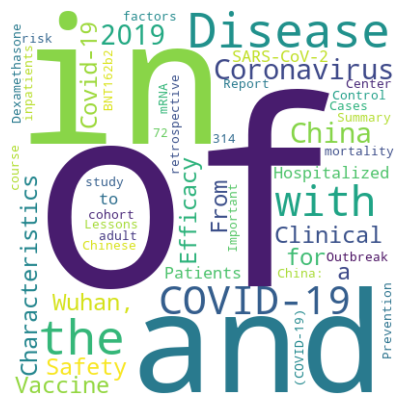

Norul de cuvinte a fost creat si salvat in 'c://2024//NLP/frecventa_cuvinte.csv'.


In [17]:
from wordcloud import WordCloud  
from collections import Counter     
import matplotlib.pyplot as plt    
import pandas as pd                
import csv                         

file_path = 'c://2024//NLP/title.txt' 

with open(file_path, 'r', encoding='utf-8') as file:  

    text_content = file.read()  

words = text_content.split()  # Separarile textului in cuvinte, folosind spatiul ca delimitator

word_frequency = Counter(words) # Cream un obiect Counter care numara aparitiile fiecarui cuvant

# Cream un nor de cuvinte cu doar cele mai frecvente 50 de cuvinte
wordcloud = WordCloud(width=400, height=400, background_color='white', max_words=50).generate_from_frequencies(word_frequency

plt.figure(figsize=(10, 5))  
plt.imshow(wordcloud, interpolation='bilinear')  
plt.axis('off') 
plt.show() 

csv_file_path = 'c://2024//NLP/frecventa_cuvinte.csv' 

with open(csv_file_path, 'w', newline='', encoding='utf-8') as csv_file:  

    csv_writer = csv.writer(csv_file)  

    csv_writer.writerow(['Cuvant', 'Frecventa'])  

    for word, frequency in word_frequency.most_common(50):  

        csv_writer.writerow([word, frequency])  

print(f"Norul de cuvinte a fost creat si salvat in '{csv_file_path}'.")  



# norul de cuvinte pe baza de cuvinte lematizate

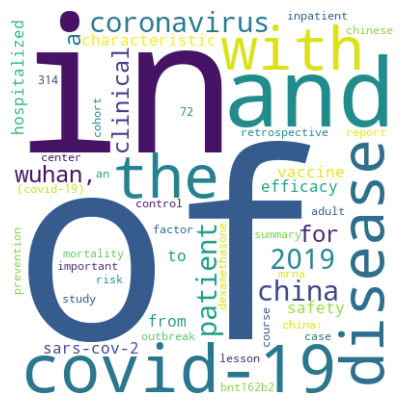

Norul de cuvinte a fost creat si salvat in 'c://2024//NLP/frecventa_cuvinte.csv'.


In [23]:
from wordcloud import WordCloud  
from collections import Counter    
import matplotlib.pyplot as plt     
import pandas as pd                 
import csv                          
import nltk                         
from nltk.stem import WordNetLemmatizer 

# Initializam lemmatizatorul
lemmatizer = WordNetLemmatizer()


file_path = 'c://2024//NLP/title.txt'  
with open(file_path, 'r', encoding='utf-8') as file:  
    text_content = file.read() 


words = text_content.split()  # Separarile textului in cuvinte, folosind spatiul ca delimitator

lemmatized_words = [lemmatizer.lemmatize(word.lower()) for word in words]  # Aplicam lematizarea pentru fiecare cuvant

word_frequency = Counter(lemmatized_words)  # Cream un obiect Counter care numara aparitiile fiecarui cuvant lematizat

wordcloud = WordCloud(width=400, height=400, background_color='white', max_words=50).generate_from_frequencies(word_frequency)

plt.figure(figsize=(10, 5)) 
plt.imshow(wordcloud, interpolation='bilinear')  
plt.axis('off')  
plt.show() 


csv_file_path = 'c://2024//NLP/frecventa_cuvinte.csv'  
with open(csv_file_path, 'w', newline='', encoding='utf-8') as csv_file:  
    csv_writer = csv.writer(csv_file) 
    csv_writer.writerow(['Cuvant', 'Frecventa'])  
    for word, frequency in word_frequency.most_common(50):  
        csv_writer.writerow([word, frequency]) 

print(f"Norul de cuvinte a fost creat si salvat in '{csv_file_path}'.") 
